💡 **Environment:** `clamp-analyses`

# LV deep-dive: summary figures

For each LV in `LVS` this notebook produces a single patchwork figure with five panels:
CLAMP pathway associations · trait associations (PhenoMExCan GLS) · top gene loadings · WikiPathways 2024 ORA · ARCHS4 Cell-lines ORA.

## Libraries

In [1]:
library(here)
library(dplyr)
library(purrr)
library(tibble)
library(stringr)
library(readr)
library(ggplot2)
library(ggrepel)
library(cowplot)

# archs4r lives in clamp-analyses env; append its library path so projections packages win conflicts
.libPaths(c(.libPaths(), "/home/msubirana/miniconda3/envs/clamp-analyses/lib/R/library"))
library(archs4r)

Warning message:
“package ‘here’ was built under R version 4.3.3”


here() starts at /home/msubirana/Documents/pivlab/clamp-analyses



Warning message:
“package ‘dplyr’ was built under R version 4.3.3”



Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




...

The following object is masked from ‘package:utils’:

    hashtab




The following objects are masked from ‘package:base’:

    :, %in%, is.double, match, order, rank




Loading required package: jsonlite




Attaching package: ‘jsonlite’




The following object is masked from ‘package:purrr’:

    flatten




## Parameters

In [2]:
LVS        <- c("LV702", "LV1620", "LV1331", "LV669")

# CLAMP pathway filter
FDR_CLAMP  <- 0.05
AUC_CLAMP  <- 0.70

# Trait filter
FDR_TRAIT  <- 0.05
MAX_TRAITS <- 20     # max traits shown in plot
WRAP_TRAIT <- 40     # line-wrap width for trait labels

# Gene loading plot
N_TOP_PCT      <- 0.01   # top fraction used as ORA query and in loading plot
N_LABEL        <- 30     # genes labelled in loading plot

# Tissue inference
N_TOP_SAMPLES  <- 1000   # top B-matrix samples for tissue inference
MAX_TISSUES    <- 20     # top tissue labels shown
WRAP_TISSUE    <- 35     # line-wrap width for tissue labels

# ORA
FDR_ORA    <- 0.05
TOP_ORA    <- 15     # max gene sets per ORA panel
WRAP_ORA   <- 35     # line-wrap width for ORA gene-set labels

# CRISPR overview
FDR_CRISPR                  <- 0.05
TOP_CRISPR_LVS_PER_DIRECTION <- 10
MAX_CRISPR_PATHS_PER_LV      <- 1
WRAP_CRISPR_PATH             <- 55

## Input

In [3]:
h5file <- here('data/archs4/human_gene_v2.5.h5')

archs4_CLAMPfull <- readRDS(here('output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/CLAMPfull_hall.rds'))

Z_mat <- data.frame(as.matrix(archs4_CLAMPfull$Z))
B_mat <- as.matrix(archs4_CLAMPfull$B)   # samples × LVs, used for tissue inference

summary_sig <- data.frame(as.matrix(archs4_CLAMPfull$summary)) %>%
  dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC)) %>%
  dplyr::filter(FDR < FDR_CLAMP, AUC > AUC_CLAMP)

archs4_CLAMPfull <- NULL

cat("Genes:", nrow(Z_mat), "| LVs:", ncol(Z_mat), "\n")
cat("Samples:", ncol(B_mat), "| LVs in B:", nrow(B_mat), "\n")
cat("Significant pathway associations:", nrow(summary_sig), "\n")

Genes: 18423 | LVs: 1728 


Samples: 605614 | LVs in B: 1728 


Significant pathway associations: 1794 


In [4]:
fgsea_all <- read.csv(
  file.path(here('output/03_model_biology/00_archs4/01_CRISPRCas9/01_biology_LVs'), 'fgsea_hi_conf_all_lvs.csv'),
  stringsAsFactors = FALSE
) %>%
  dplyr::mutate(
    padj = as.numeric(padj),
    NES  = as.numeric(NES)
  )

fgsea_best <- fgsea_all %>%
  dplyr::group_by(lv) %>%
  dplyr::summarize(gsea_padj = min(padj, na.rm = TRUE), .groups = "drop")

cat("LVs with CRISPR signal:", nrow(dplyr::filter(fgsea_best, gsea_padj < 0.05)), "\n")

LVs with CRISPR signal: 93 


In [5]:
traits_all <- readr::read_tsv(
  here("data/archs4/traits/hall_coverage_rs100_seed_1_CLAMPfull_hall/gls-summary-phenomexcan.tsv.gz"),
  show_col_types = FALSE
) %>%
  dplyr::select(!phenotype) %>%
  dplyr::rename(phenotype = phenotype_desc, LV = lv, FDR = fdr)

desc_to_n <- readr::read_tsv(
  here("output/01_model_building/02_gtex/01_CLAMP/phenomexcan_simplified_phenotypes_info.tsv.gz"),
  show_col_types = FALSE
) %>%
  dplyr::mutate(n_eff = dplyr::coalesce(n, n_cases + n_controls)) %>%
  dplyr::filter(!is.na(n_eff)) %>%
  dplyr::group_by(description) %>%
  dplyr::summarize(n_eff = max(n_eff, na.rm = TRUE), .groups = "drop")

cat("Trait associations loaded.", "\n")

Trait associations loaded. 


## Shared theme

In [6]:
lollipop_theme <- theme_minimal(base_size = 16) +
  theme(
    plot.background    = element_rect(fill = "white", colour = NA),
    panel.background   = element_rect(fill = "white", colour = "#555555", linewidth = 0.4),
    panel.grid.major.x = element_line(colour = "#e0e0e0", linewidth = 0.3),
    panel.grid.major.y = element_blank(),
    panel.grid.minor   = element_blank(),
    axis.text.y        = element_text(size = 11, colour = "grey15", lineheight = 0.85),
    axis.text.x        = element_text(size = 12),
    axis.title.x       = element_text(size = 13, margin = margin(t = 6)),
    axis.ticks.y       = element_blank(),
    legend.position    = "bottom",
    legend.justification = "center",
    legend.title       = element_text(size = 12, face = "bold"),
    legend.text        = element_text(size = 11),
    legend.key         = element_blank(),
    legend.box         = "horizontal",
    legend.margin      = margin(4, 6, 4, 6),
    legend.spacing.x   = unit(0.8, "cm"),
    plot.margin        = margin(8, 16, 8, 8)
  )

## Plot functions

In [7]:
make_pathway_plot <- function(lv_name) {
  df <- summary_sig %>%
    dplyr::filter(LV == lv_name) %>%
    dplyr::mutate(
      clamp_neg_log_fdr = -log10(pmax(FDR, .Machine$double.xmin)),
      pathway_wrap = stringr::str_wrap(
        stringr::str_replace_all(pathway, "_", " "),
        width = 40
      )
    ) %>%
    dplyr::arrange(clamp_neg_log_fdr) %>%
    dplyr::mutate(pathway_label = factor(pathway_wrap, levels = unique(pathway_wrap)))

  if (nrow(df) == 0) {
    return(
      ggplot() + theme_void() +
        annotate("text", x = 0.5, y = 0.5, label = paste(lv_name, "\nno pathways"),
                 size = 4, colour = "grey60", hjust = 0.5)
    )
  }

  fdr_max <- max(df$clamp_neg_log_fdr, na.rm = TRUE)

  ggplot(df, aes(x = clamp_neg_log_fdr, y = pathway_label)) +
    geom_segment(
      aes(x = 0, xend = clamp_neg_log_fdr, yend = pathway_label),
      colour = "#d0d0d0", linewidth = 0.4, linetype = "dotted"
    ) +
    geom_point(
      aes(size = AUC, fill = clamp_neg_log_fdr),
      shape = 21, colour = "#333333", stroke = 0.4, alpha = 0.9
    ) +
    scale_fill_gradient(
      low = "#e5f5e0", high = "#00441b",
      limits = c(0, fdr_max),
      name   = expression("-log"[10]*"(FDR"[CLAMP]*")"),
      guide  = guide_colourbar(
        title.position = "top", title.hjust = 0.5,
        barwidth = unit(4, "cm"), barheight = unit(0.4, "cm"), order = 1
      )
    ) +
    scale_size_continuous(
      range = c(3, 9), limits = c(0.6, 1.0), breaks = c(0.7, 0.8, 0.9, 1.0),
      name  = "AUC",
      guide = guide_legend(title.position = "top", title.hjust = 0.5, order = 2)
    ) +
    scale_x_continuous(
      limits = c(0, fdr_max * 1.06),
      breaks = pretty(c(0, fdr_max), n = 4),
      expand = c(0, 0)
    ) +
    labs(x = expression("-log"[10]*"(FDR"[CLAMP]*")"), y = NULL) +
    lollipop_theme
}

In [8]:
make_trait_plot <- function(lv_name) {
  df <- traits_all %>%
    dplyr::filter(LV == lv_name, FDR < FDR_TRAIT) %>%
    dplyr::left_join(desc_to_n, by = c("phenotype" = "description")) %>%
    dplyr::mutate(
      # Replace Unicode typographic quotes with ASCII for PNG font rendering
      phenotype = stringr::str_replace_all(
        phenotype,
        c("'" = "'", "'" = "'", "“" = "\"", "”" = "\"")
      ),
      trait_neg_log_fdr = -log10(pmax(FDR, .Machine$double.xmin))
    ) %>%
    dplyr::arrange(dplyr::desc(trait_neg_log_fdr)) %>%
    dplyr::distinct(phenotype, .keep_all = TRUE) %>%
    dplyr::slice_head(n = MAX_TRAITS) %>%
    dplyr::mutate(
      trait_wrap  = stringr::str_wrap(phenotype, width = WRAP_TRAIT),
      trait_label = factor(trait_wrap, levels = rev(unique(trait_wrap)))
    )

  if (nrow(df) == 0) {
    return(
      ggplot() + theme_void() +
        annotate("text", x = 0.5, y = 0.5, label = paste(lv_name, "\nno traits"),
                 size = 4, colour = "grey60", hjust = 0.5)
    )
  }

  fdr_max <- max(df$trait_neg_log_fdr, na.rm = TRUE)

  ggplot(df, aes(x = trait_neg_log_fdr, y = trait_label)) +
    geom_segment(
      aes(x = 0, xend = trait_neg_log_fdr, yend = trait_label),
      colour = "#cccccc", linewidth = 0.5, linetype = "dotted"
    ) +
    geom_point(
      aes(size = sqrt(n_eff) / 1.8, fill = trait_neg_log_fdr),
      shape = 21, colour = "#333333", stroke = 0.5, alpha = 0.9
    ) +
    scale_fill_gradient(
      low = "#e5f5e0", high = "#00441b",
      limits = c(0, fdr_max),
      name   = expression("-log"[10]*"(FDR"[trait]*")"),
      guide  = guide_colourbar(
        title.position = "top", title.hjust = 0.5,
        barwidth = unit(4, "cm"), barheight = unit(0.4, "cm"), order = 1
      )
    ) +
    scale_size_continuous(
      range  = c(3, 11),
      breaks = sqrt(c(10000, 100000, 300000)) / 1.8,
      labels = c("10k", "100k", "300k"),
      name   = "N cases",
      guide  = guide_legend(title.position = "top", title.hjust = 0.5, order = 2)
    ) +
    scale_x_continuous(
      limits = c(0, fdr_max * 1.06),
      breaks = seq(0, ceiling(fdr_max), by = 1),
      expand = c(0, 0)
    ) +
    labs(x = expression("-log"[10]*"(FDR"[trait]*")"), y = NULL) +
    lollipop_theme
}

In [9]:
make_gene_plot <- function(lv_name) {
  all_genes <- rownames(Z_mat)
  n_top     <- ceiling(length(all_genes) * N_TOP_PCT)
  lv_vec    <- setNames(Z_mat[, lv_name], all_genes)
  ord       <- order(lv_vec, decreasing = TRUE)

  plot_df  <- data.frame(
    rank    = seq_len(n_top),
    gene    = all_genes[ord][seq_len(n_top)],
    loading = lv_vec[ord][seq_len(n_top)],
    stringsAsFactors = FALSE
  )
  label_df <- plot_df %>% dplyr::slice_head(n = N_LABEL)

  ggplot(plot_df, aes(x = rank, y = loading)) +
    geom_point(size = 1.2, color = "grey75") +
    geom_point(data = label_df, color = "#C23B22", size = 1.8) +
    ggrepel::geom_text_repel(
      data               = label_df,
      aes(label = gene),
      size               = 3.2,
      fontface           = "italic",
      direction          = "y",
      hjust              = 0,
      seed               = 42,
      max.overlaps       = Inf,
      min.segment.length = 0,
      box.padding        = 0.3,
      point.padding      = 0.2,
      nudge_x            = 8,
      segment.color      = "grey60",
      segment.size       = 0.25
    ) +
    coord_cartesian(clip = "off") +
    scale_x_continuous(expand = expansion(mult = c(0.02, 0.28))) +
    labs(y = "Loading") +
    theme_classic(base_size = 13) +
    theme(
      plot.background = element_rect(fill = "white", colour = NA),
      axis.line    = element_line(color = "black", linewidth = 0.4),
      axis.ticks   = element_line(color = "black", linewidth = 0.3),
      axis.text    = element_text(size = 12),
      axis.title.y = element_text(size = 13),
      axis.text.x  = element_blank(),
      axis.ticks.x = element_blank(),
      axis.title.x = element_blank(),
      plot.margin  = margin(5, 32, 5, 5)
    )
}

In [10]:
make_tissue_plot <- function(lv_name) {
  B_scores  <- sort(B_mat[lv_name, ], decreasing = TRUE)
  top_samps <- names(B_scores)[seq_len(N_TOP_SAMPLES)]

  meta <- tryCatch({
    as.data.frame(
      archs4r::a4.meta.samples(
        h5file, top_samps,
        meta_fields = c("geo_accession", "source_name_ch1"),
        silent = TRUE
      ),
      stringsAsFactors = FALSE
    )[top_samps, , drop = FALSE]
  }, error = function(e) {
    message("tissue metadata fetch failed: ", conditionMessage(e))
    NULL
  })

  if (is.null(meta) || nrow(meta) == 0) {
    return(
      ggplot() + theme_void() +
        annotate("text", x = 0.5, y = 0.5, label = "no tissue data",
                 size = 5, colour = "grey60", hjust = 0.5)
    )
  }

  source_df <- meta %>%
    tibble::rownames_to_column("sample_id") %>%
    dplyr::mutate(
      source = stringr::str_to_lower(stringr::str_trim(source_name_ch1))
    ) %>%
    dplyr::count(source, sort = TRUE, name = "count") %>%
    dplyr::slice_head(n = MAX_TISSUES) %>%
    dplyr::arrange(count) %>%
    dplyr::mutate(
      source_wrap  = stringr::str_wrap(source, width = WRAP_TISSUE),
      source_label = factor(source_wrap, levels = unique(source_wrap))
    )

  x_max <- max(source_df$count, na.rm = TRUE) * 1.06

  ggplot(source_df, aes(x = count, y = source_label)) +
    geom_segment(
      aes(x = 0, xend = count, yend = source_label),
      colour = "#d0d0d0", linewidth = 0.4, linetype = "dotted"
    ) +
    geom_point(
      aes(fill = count),
      size = 4, shape = 21, colour = "#333333", stroke = 0.4, alpha = 0.9
    ) +
    scale_fill_gradient(
      low  = "#e5f5e0", high = "#00441b",
      name = "Count",
      guide = guide_colourbar(
        title.position = "top", title.hjust = 0.5,
        barwidth = unit(3.5, "cm"), barheight = unit(0.35, "cm")
      )
    ) +
    scale_x_continuous(limits = c(0, x_max), expand = c(0, 0)) +
    labs(x = paste0("Samples (top ", N_TOP_SAMPLES, ")"), y = NULL) +
    lollipop_theme
}

## ORA setup

In [11]:
parse_enrichr_gmt <- function(url) {
  lines <- readLines(url, warn = FALSE)
  sets  <- lapply(lines, function(l) {
    parts <- strsplit(l, "\t")[[1]]
    list(name = parts[1], genes = parts[-(1:2)])
  })
  setNames(lapply(sets, `[[`, "genes"), sapply(sets, `[[`, "name"))
}

cat("Fetching WikiPathways GMT...\n")
wiki_t2g   <- parse_enrichr_gmt("https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=WikiPathways_2024_Human")
cat("Fetching ARCHS4 Cell-lines GMT...\n")
archs4_t2g <- parse_enrichr_gmt("https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=ARCHS4_Cell-lines")
cat("Done. WikiPathways:", length(wiki_t2g), "sets | ARCHS4:", length(archs4_t2g), "sets\n")

Fetching WikiPathways GMT...


Fetching ARCHS4 Cell-lines GMT...


Done. WikiPathways: 829 sets | ARCHS4: 126 sets


In [12]:
run_ora <- function(query, term2gene, background, min_gs = 10, max_gs = 500) {
  bg <- unique(background)
  q  <- intersect(query, bg)
  N  <- length(bg)
  K  <- length(q)
  if (K == 0) return(NULL)

  res <- purrr::map_dfr(names(term2gene), function(gs_name) {
    gs <- intersect(term2gene[[gs_name]], bg)
    M  <- length(gs)
    if (M < min_gs || M > max_gs) return(NULL)
    k  <- length(intersect(q, gs))
    if (k == 0) return(NULL)
    data.frame(
      ID        = gs_name,
      Count     = k,
      GeneRatio = paste0(k, "/", K),
      BgRatio   = paste0(M, "/", N),
      pvalue    = phyper(k - 1, M, N - M, K, lower.tail = FALSE),
      geneID    = paste(sort(intersect(q, gs)), collapse = "/"),
      stringsAsFactors = FALSE
    )
  })

  if (is.null(res) || nrow(res) == 0) return(NULL)
  res$p.adjust <- p.adjust(res$pvalue, method = "BH")
  dplyr::arrange(res, p.adjust)
}

plot_ora <- function(ora_df, top_k = TOP_ORA, fdr_thresh = FDR_ORA, wrap_w = WRAP_ORA) {
  blank <- ggplot() + theme_void() +
    annotate("text", x = 0.5, y = 0.5, label = "no significant hits",
             size = 3.5, colour = "grey60", hjust = 0.5)

  if (is.null(ora_df) || nrow(ora_df) == 0) return(blank)

  df <- ora_df %>%
    dplyr::filter(p.adjust < fdr_thresh) %>%
    dplyr::slice_head(n = top_k)

  if (nrow(df) == 0) return(blank)

  df <- df %>%
    dplyr::mutate(
      gene_ratio  = purrr::map_dbl(GeneRatio, ~ { s <- strsplit(.x, "/")[[1]]; as.integer(s[1]) / as.integer(s[2]) }),
      bg_ratio    = purrr::map_dbl(BgRatio,   ~ { s <- strsplit(.x, "/")[[1]]; as.integer(s[1]) / as.integer(s[2]) }),
      fold_enrich = gene_ratio / bg_ratio,
      neg_log_fdr = pmin(-log10(pmax(p.adjust, .Machine$double.xmin)), 10),
      label = stringr::str_wrap(
        stringr::str_replace_all(ID, "_", " "),
        width = wrap_w
      )
    ) %>%
    dplyr::arrange(fold_enrich) %>%
    dplyr::mutate(label = factor(label, levels = unique(label)))

  fdr_max   <- ceiling(max(df$neg_log_fdr, na.rm = TRUE))
  count_max <- max(df$Count, na.rm = TRUE)

  ggplot(df, aes(x = fold_enrich, y = label)) +
    geom_segment(
      aes(x = 0, xend = fold_enrich, yend = label),
      colour = "#d0d0d0", linewidth = 0.4, linetype = "dotted"
    ) +
    geom_point(
      aes(size = Count, fill = neg_log_fdr),
      shape = 21, colour = "#333333", stroke = 0.4, alpha = 0.9
    ) +
    scale_fill_gradient(
      low = "#e5f5e0", high = "#00441b",
      limits = c(0, fdr_max),
      name   = expression("-log"[10]*"(FDR)"),
      guide  = guide_colourbar(
        title.position = "top", title.hjust = 0.5,
        barwidth = unit(3.5, "cm"), barheight = unit(0.35, "cm"), order = 1
      )
    ) +
    scale_size_continuous(
      range = c(3, 9),
      limits = c(1, count_max),
      name  = "Gene count",
      guide = guide_legend(title.position = "top", title.hjust = 0.5, order = 2)
    ) +
    scale_x_continuous(
      limits = c(0, max(df$fold_enrich) * 1.06),
      expand = c(0, 0)
    ) +
    labs(x = "Fold Enrichment", y = NULL) +
    lollipop_theme
}

make_ora_plots <- function(lv_name) {
  all_genes <- rownames(Z_mat)
  n_top     <- ceiling(length(all_genes) * N_TOP_PCT)
  lv_vec    <- setNames(Z_mat[, lv_name], all_genes)
  lv_query  <- names(sort(lv_vec, decreasing = TRUE))[seq_len(n_top)]

  ora_wiki   <- run_ora(lv_query, wiki_t2g,   all_genes)
  ora_archs4 <- run_ora(lv_query, archs4_t2g, all_genes, max_gs = 3000)

  list(
    wiki      = plot_ora(ora_wiki),
    archs4    = plot_ora(ora_archs4),
    wiki_df   = ora_wiki,
    archs4_df = ora_archs4
  )
}

## CRISPR pathway overview

In [ ]:
clean_crispr_pathway_label <- function(x) {
  x %>%
    stringr::str_remove("^REACTOME_REACTOME_") %>%
    stringr::str_remove("^GOCC_GOCC_") %>%
    stringr::str_remove("^HALL_HALLMARK_") %>%
    stringr::str_remove("^C8_C8_") %>%
    stringr::str_replace_all("_", " ") %>%
    stringr::str_squish() %>%
    stringr::str_to_upper()
}

make_crispr_pathway_overview <- function(fgsea_df = fgsea_all,
                                         pathway_df = summary_sig,
                                         crispr_fdr_cutoff = FDR_CRISPR,
                                         top_n_per_direction = TOP_CRISPR_LVS_PER_DIRECTION,
                                         max_paths_per_lv = MAX_CRISPR_PATHS_PER_LV,
                                         pathway_fdr_cutoff = FDR_CLAMP,
                                         auc_cutoff = AUC_CLAMP,
                                         wrap_w = WRAP_CRISPR_PATH) {
  empty_plot <- function(label) {
    p <- ggplot() +
      theme_void() +
      annotate("text", x = 0.5, y = 0.5, label = label, size = 4, colour = "grey60")
    attr(p, "suggested_width") <- 8
    attr(p, "suggested_height") <- 5
    p
  }

  crispr_lv <- fgsea_df %>%
    dplyr::filter(
      !is.na(padj),
      !is.na(NES),
      pathway %in% c("gene_set_increase", "gene_set_decrease")
    ) %>%
    dplyr::group_by(lv, pathway) %>%
    dplyr::slice_min(order_by = padj, n = 1, with_ties = FALSE) %>%
    dplyr::ungroup() %>%
    dplyr::mutate(
      LV = lv,
      signed_nes = dplyr::if_else(pathway == "gene_set_decrease", -abs(NES), abs(NES)),
      direction = dplyr::if_else(pathway == "gene_set_decrease",
                                 "Lipid-decrease genes", "Lipid-increase genes"),
      crispr_neg_log_fdr = -log10(pmax(padj, .Machine$double.xmin)),
      abs_signed_nes = abs(signed_nes)
    ) %>%
    dplyr::filter(padj < crispr_fdr_cutoff)

  if (nrow(crispr_lv) == 0) {
    return(empty_plot("no significant CRISPR LVs"))
  }

  crispr_lv <- crispr_lv %>%
    dplyr::group_by(LV) %>%
    dplyr::arrange(padj, dplyr::desc(abs_signed_nes), .by_group = TRUE) %>%
    dplyr::slice_head(n = 1) %>%
    dplyr::ungroup()

  top_paths <- pathway_df %>%
    dplyr::filter(LV %in% crispr_lv$LV, FDR < pathway_fdr_cutoff, AUC > auc_cutoff) %>%
    dplyr::group_by(LV) %>%
    dplyr::arrange(dplyr::desc(AUC), FDR, .by_group = TRUE) %>%
    dplyr::slice_head(n = max_paths_per_lv) %>%
    dplyr::ungroup()

  plot_df <- top_paths %>%
    dplyr::inner_join(crispr_lv, by = "LV", suffix = c("_clamp", "_crispr")) %>%
    dplyr::group_by(direction) %>%
    dplyr::arrange(padj, dplyr::desc(abs_signed_nes), .by_group = TRUE) %>%
    dplyr::slice_head(n = top_n_per_direction) %>%
    dplyr::ungroup() %>%
    dplyr::arrange(dplyr::desc(signed_nes), LV, dplyr::desc(AUC), FDR) %>%
    dplyr::mutate(
      pathway_clean = clean_crispr_pathway_label(pathway_clamp),
      row_label = stringr::str_wrap(paste0(LV, " | ", pathway_clean), width = wrap_w),
      row_label = factor(row_label, levels = rev(unique(row_label)))
    )

  if (nrow(plot_df) == 0) {
    return(empty_plot("no annotated significant CRISPR LVs"))
  }

  x_lim <- max(abs(plot_df$signed_nes), na.rm = TRUE) * 1.08
  if (!is.finite(x_lim) || x_lim == 0) x_lim <- 1
  size_breaks <- pretty(plot_df$crispr_neg_log_fdr, n = 4)

  p <- ggplot(plot_df, aes(x = signed_nes, y = row_label)) +
    geom_vline(xintercept = 0, linetype = "dotted", colour = "grey55", linewidth = 0.35) +
    geom_point(aes(size = crispr_neg_log_fdr, colour = direction), alpha = 0.9) +
    scale_colour_manual(
      values = c("Lipid-decrease genes" = "#2C7FB8", "Lipid-increase genes" = "#D95F0E"),
      name = NULL
    ) +
    scale_size_continuous(
      range = c(2.5, 8),
      breaks = size_breaks,
      name = "-log10(FDR)",
      guide = guide_legend(override.aes = list(colour = "#222222"))
    ) +
    scale_x_continuous(
      limits = c(-x_lim, x_lim),
      breaks = pretty(c(-x_lim, x_lim), n = 5),
      expand = expansion(mult = c(0.02, 0.02))
    ) +
    labs(x = "signed NES (CRISPR lipid gene set)", y = NULL) +
    theme_bw(base_size = 10) +
    theme(
      panel.grid.major = element_line(colour = "#e5e5e5", linewidth = 0.3),
      panel.grid.minor = element_blank(),
      axis.text.y = element_text(size = 8, colour = "grey30", lineheight = 0.9),
      axis.text.x = element_text(size = 9, colour = "grey30"),
      axis.title.x = element_text(size = 10, margin = margin(t = 5)),
      axis.ticks.y = element_blank(),
      legend.position = "right",
      legend.title = element_text(size = 9),
      legend.text = element_text(size = 8),
      legend.key = element_blank(),
      plot.margin = margin(5, 10, 5, 5, "mm")
    )

  attr(p, "suggested_width") <- 8.5
  attr(p, "suggested_height") <- max(6, 0.35 * nrow(plot_df) + 2)
  attr(p, "plot_data") <- plot_df
  p
}

In [ ]:
p_crispr_overview <- make_crispr_pathway_overview()

options(
  repr.plot.width = attr(p_crispr_overview, "suggested_width"),
  repr.plot.height = attr(p_crispr_overview, "suggested_height")
)

print(p_crispr_overview)

## Summary figures

In [13]:
make_summary_figure <- function(lv_name) {
  cat("Building figure for", lv_name, "...\n")

  p_path   <- make_pathway_plot(lv_name)
  p_trait  <- make_trait_plot(lv_name)
  p_gene   <- make_gene_plot(lv_name)
  p_tissue <- make_tissue_plot(lv_name)
  ora      <- make_ora_plots(lv_name)
  p_wiki   <- ora$wiki
  p_archs4 <- ora$archs4

  # 3 × 2 equal-panel grid
  # Row 1: CLAMP pathways | traits          | gene loading
  # Row 2: WikiPathways   | ARCHS4 cells    | tissue (B-matrix top samples)
  title_row <- cowplot::ggdraw() +
    cowplot::draw_label(lv_name, fontface = "bold", size = 22, hjust = 0.5, x = 0.5)

  main_grid <- cowplot::plot_grid(
    p_path,  p_trait,  p_gene,
    p_wiki,  p_archs4, p_tissue,
    ncol = 3, nrow = 2
  )

  cowplot::plot_grid(
    title_row, main_grid,
    ncol = 1, rel_heights = c(0.04, 0.96)
  )
}

Building figure for LV702 ...


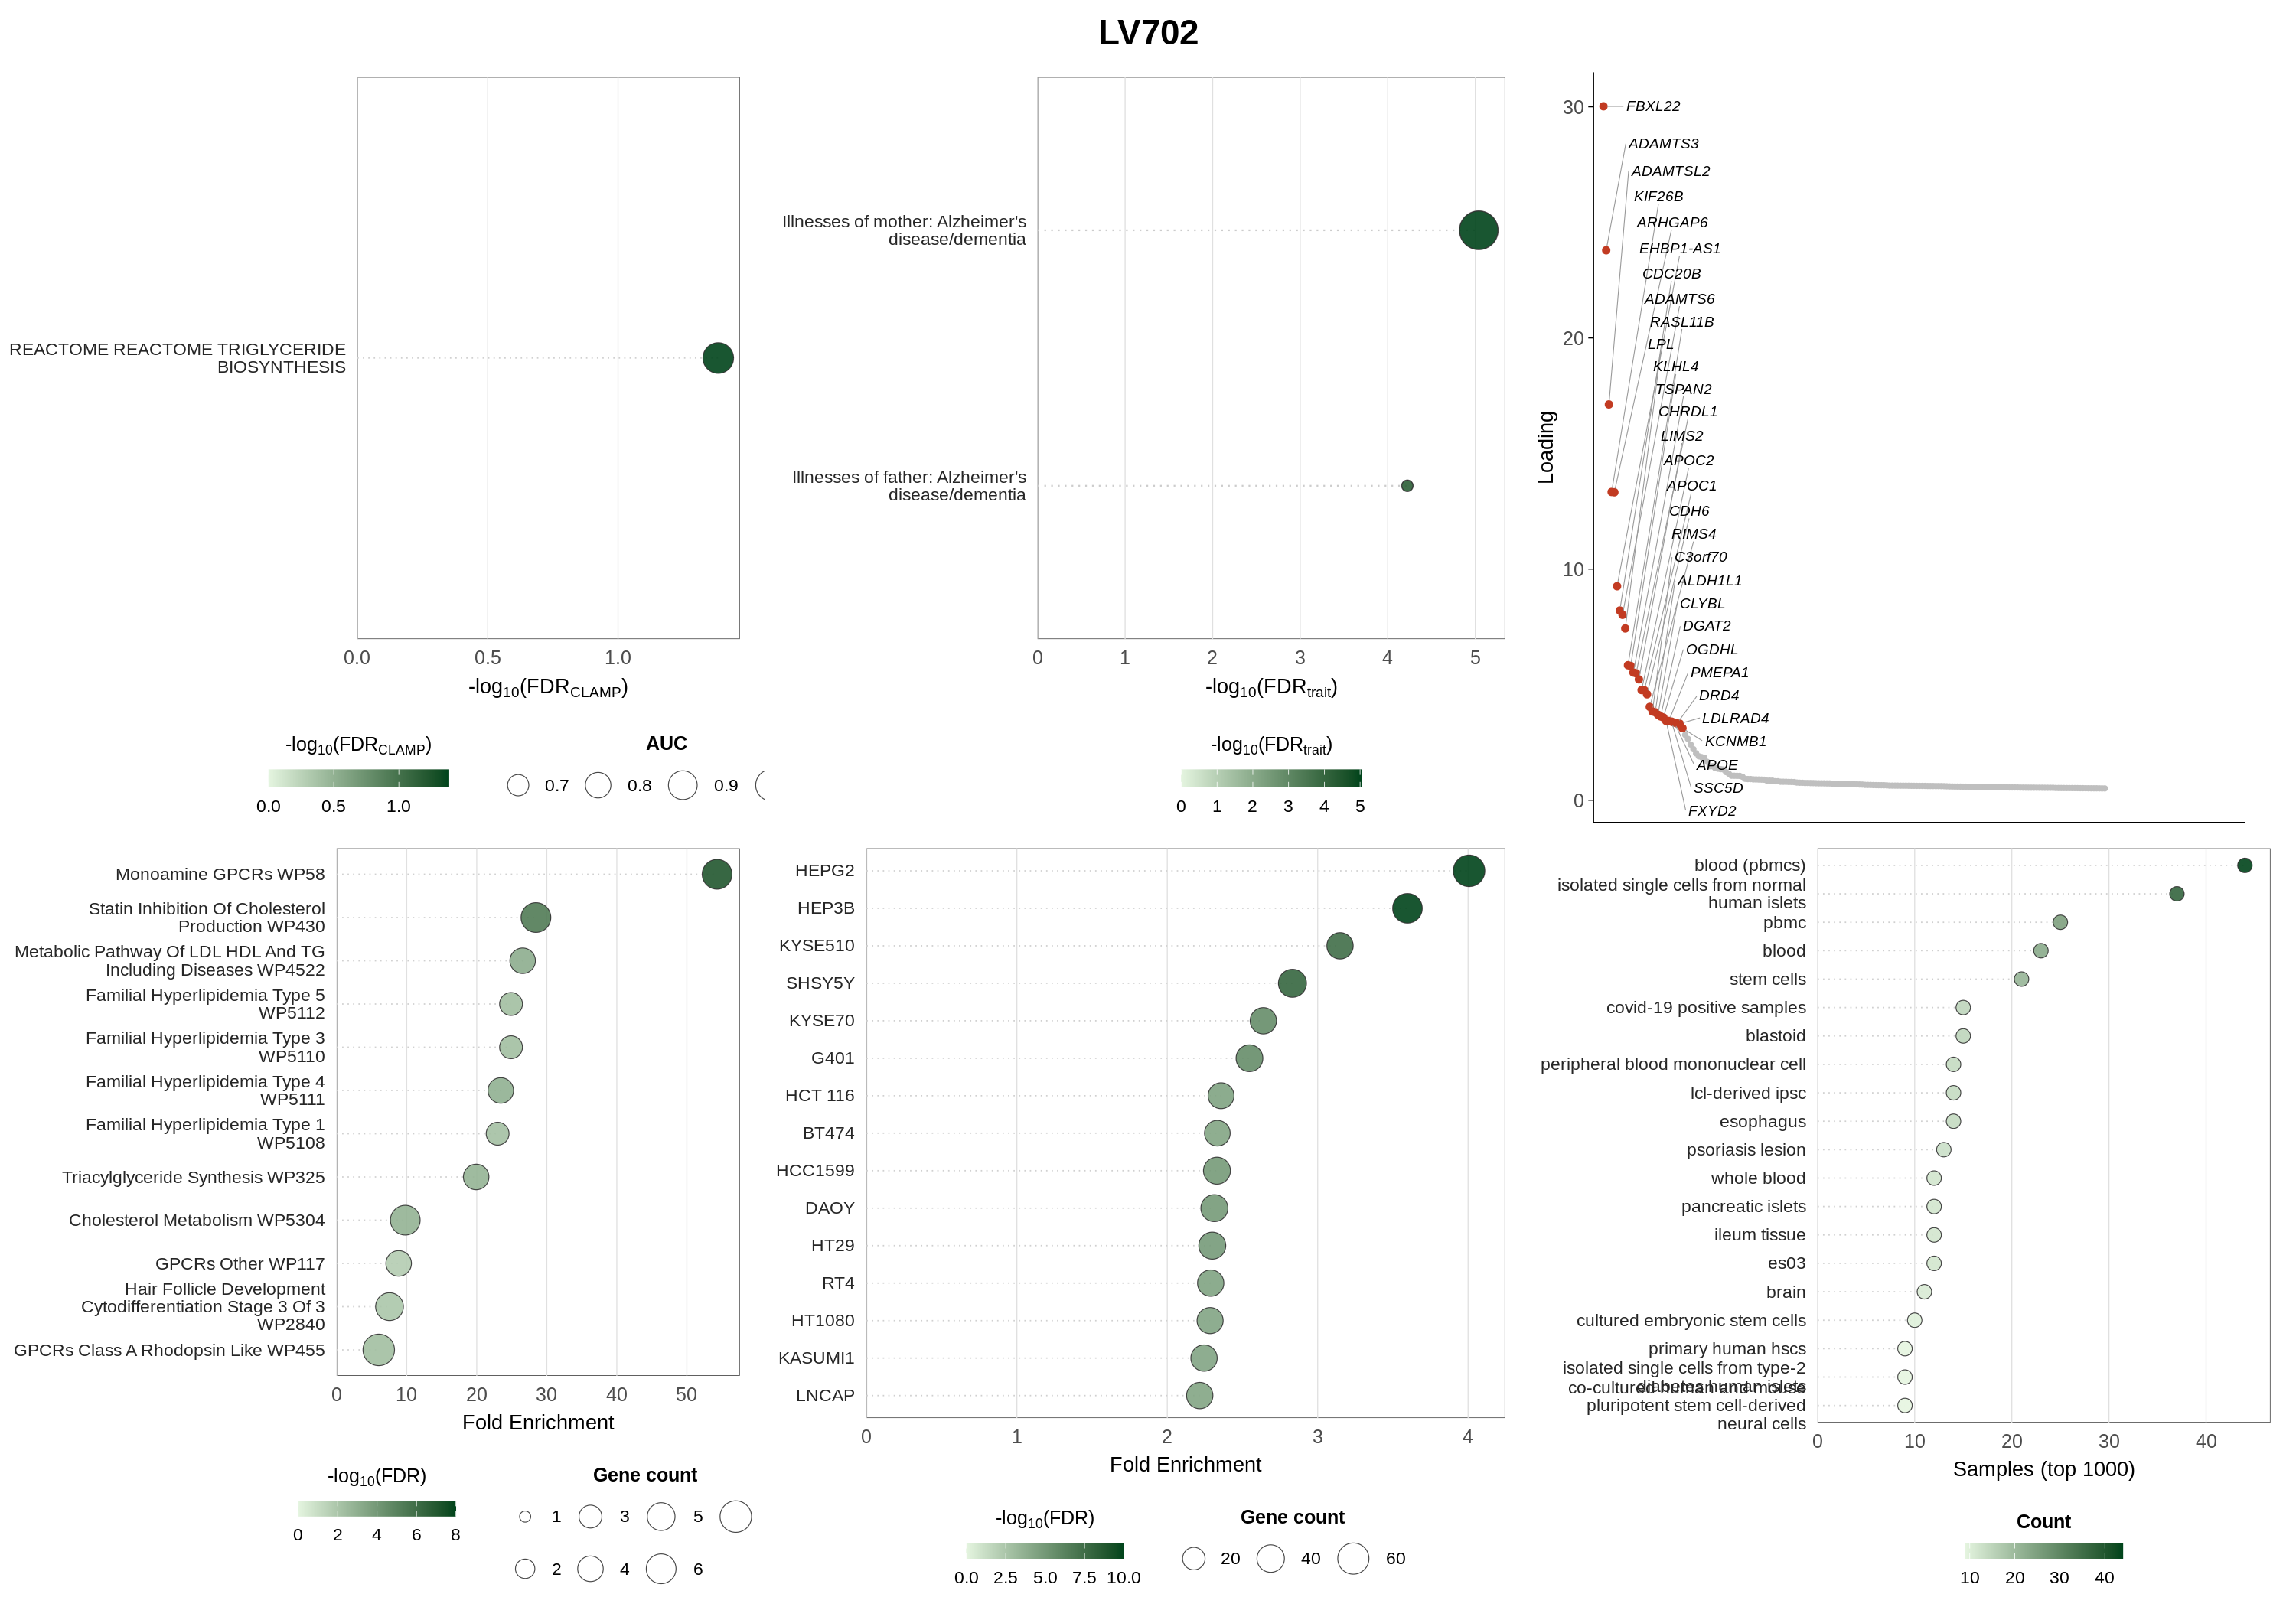


Building figure for LV1620 ...


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Alzheimer’s disease' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Alzheimer’s disease' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Alzheimer’s disease' in 'mbcsToSbcs': dot substituted for <99>”


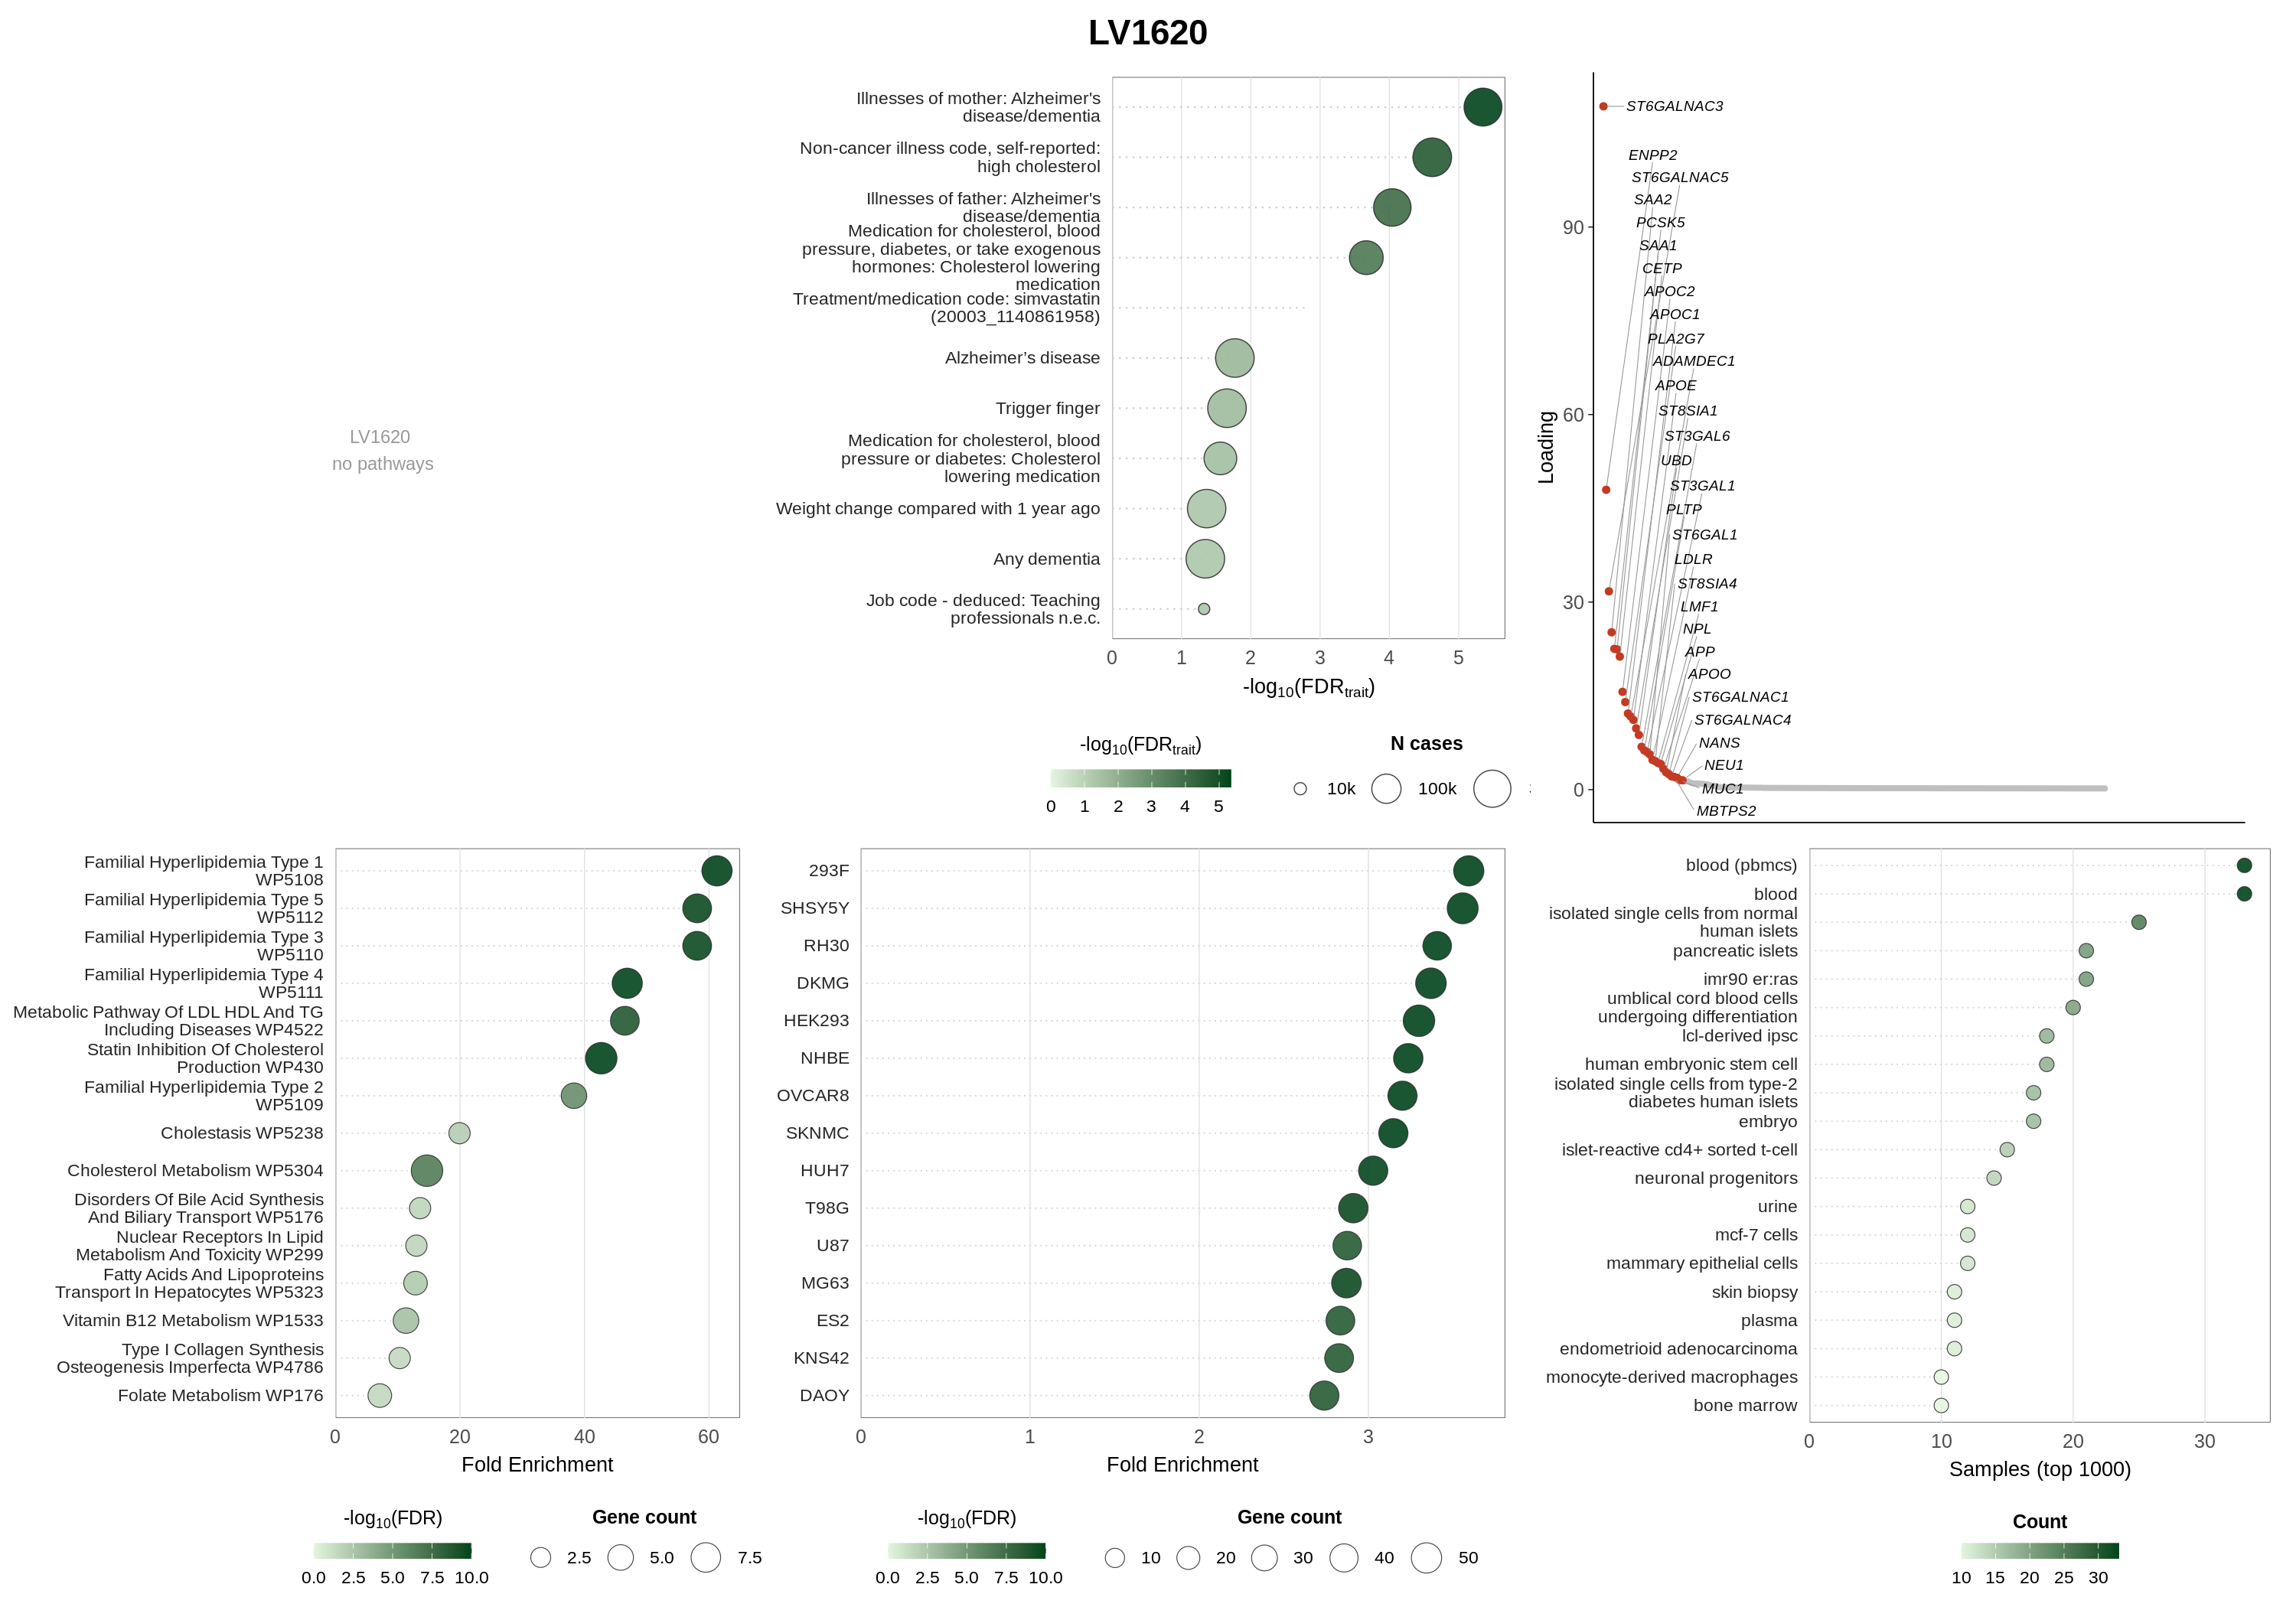


Building figure for LV1331 ...


Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Alzheimer’s disease' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Alzheimer’s disease' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Alzheimer’s disease' in 'mbcsToSbcs': dot substituted for <99>”


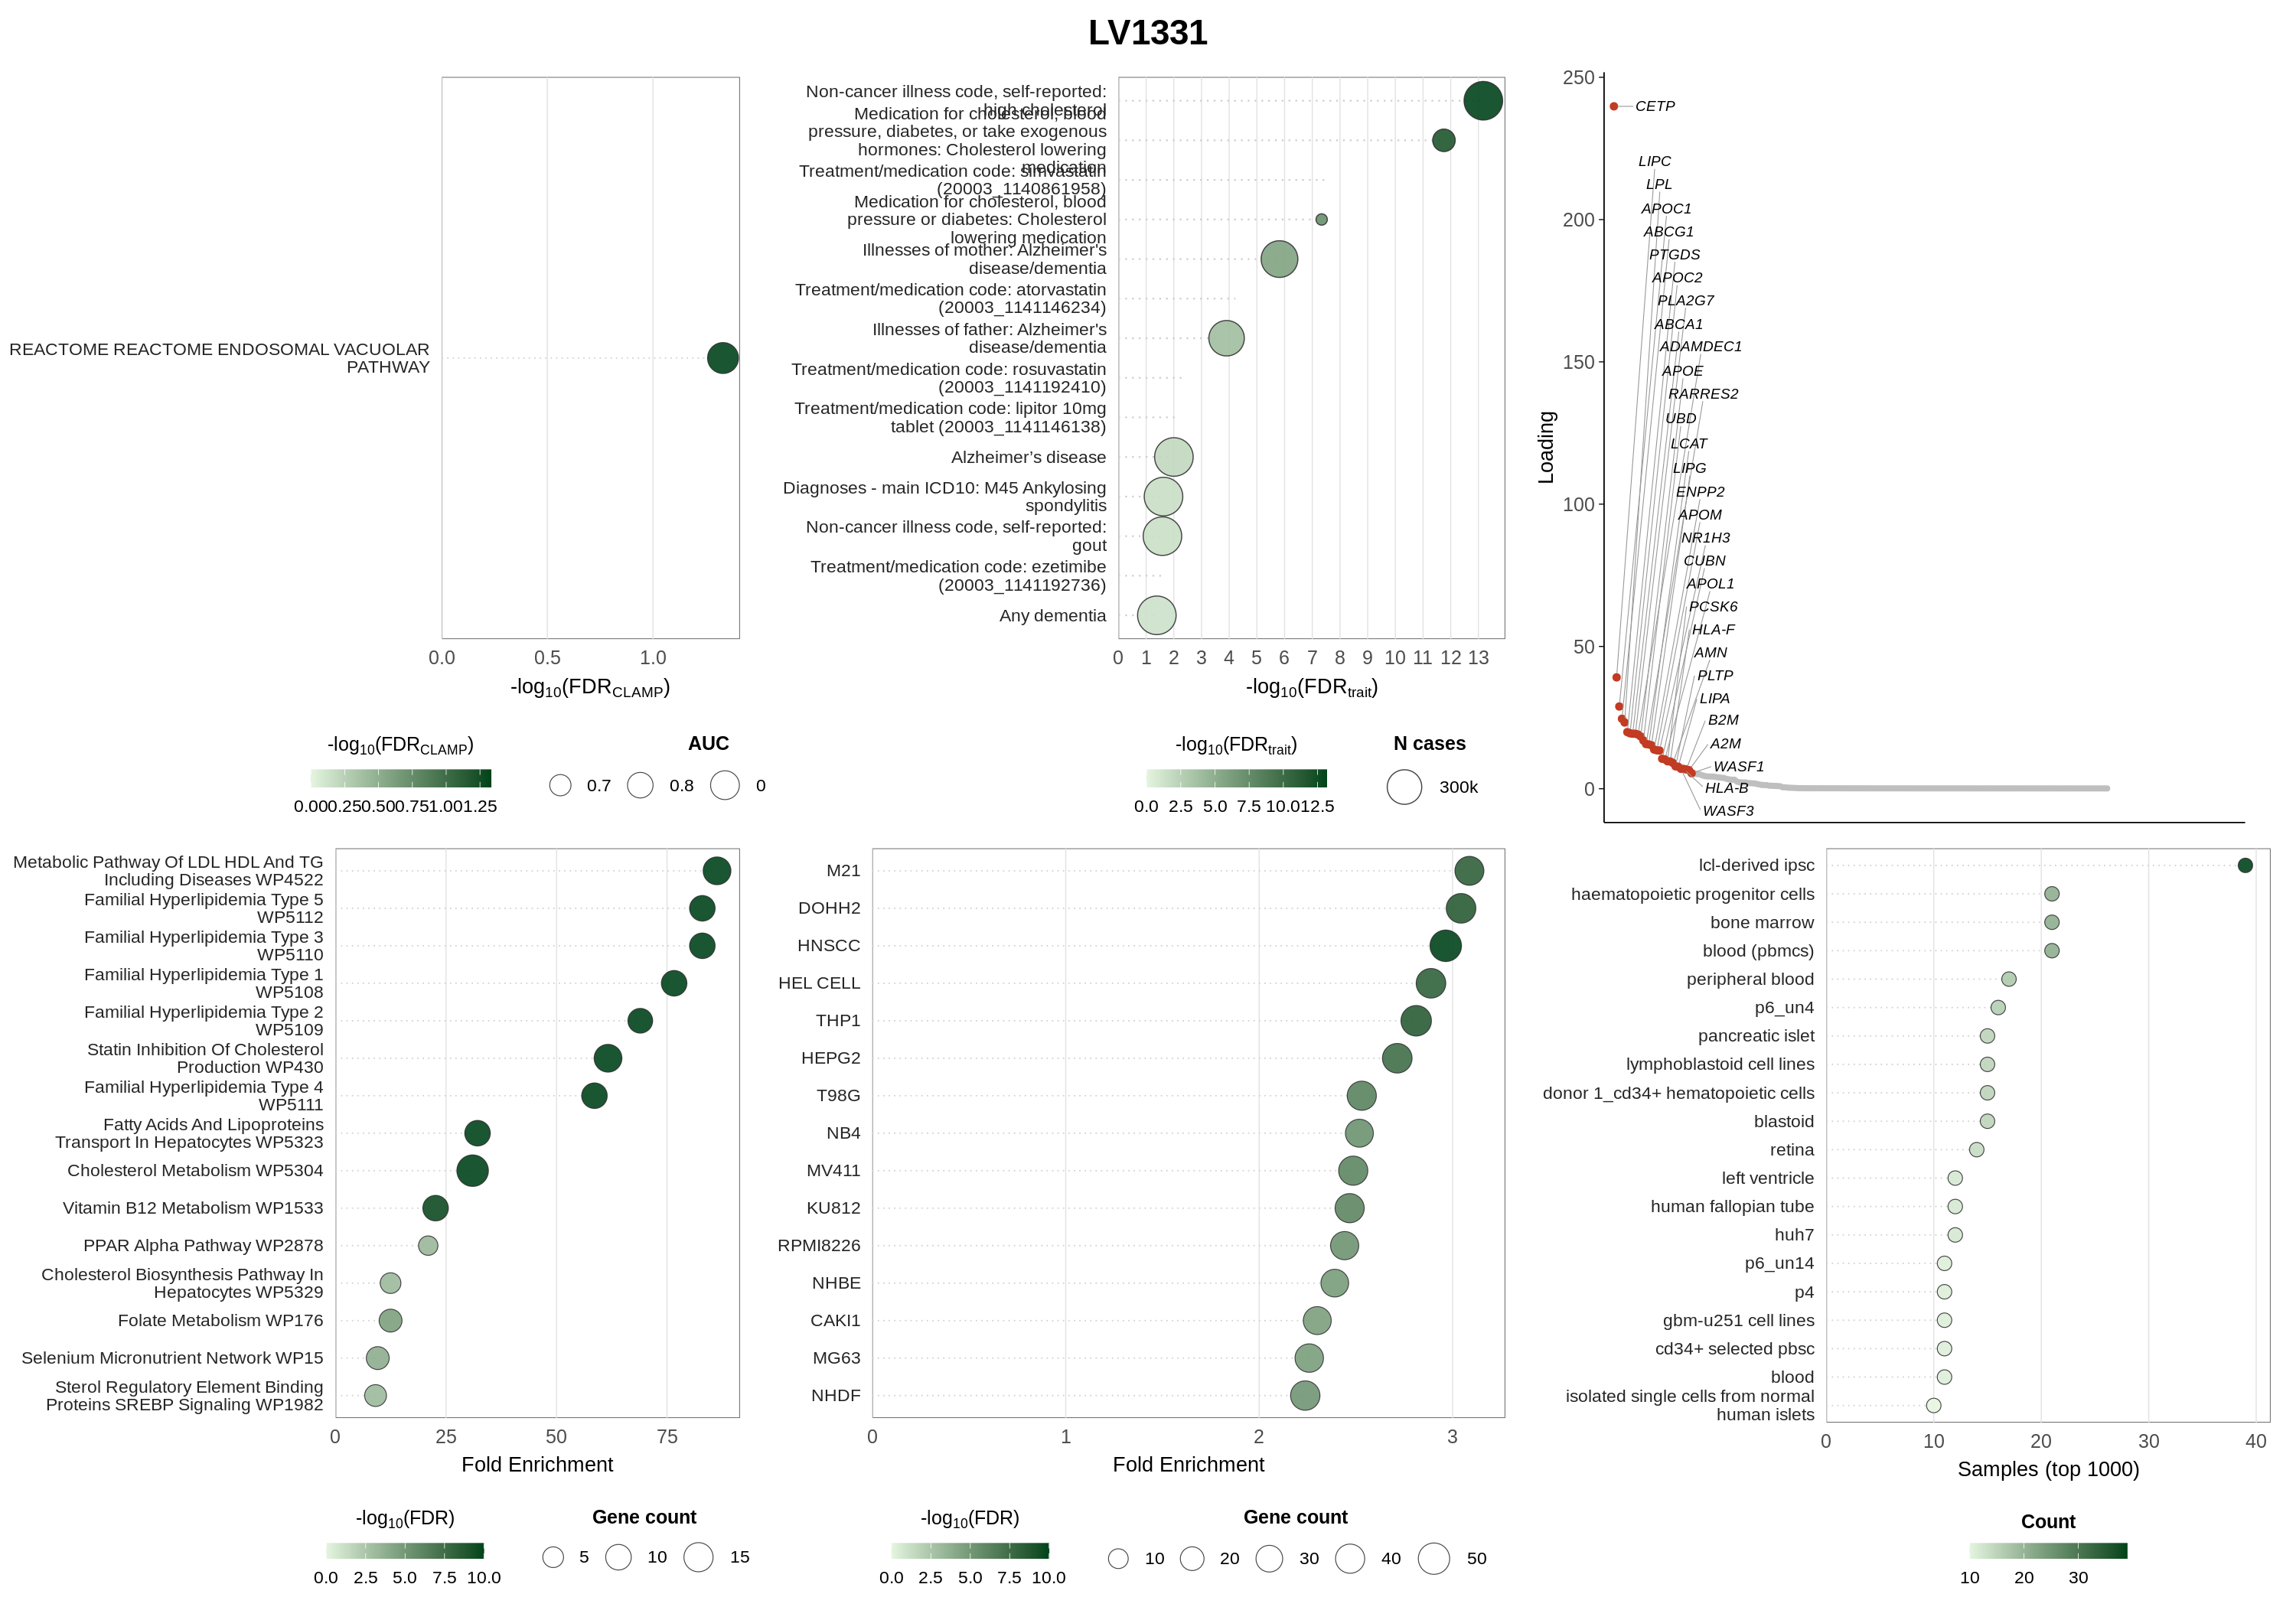


Building figure for LV669 ...


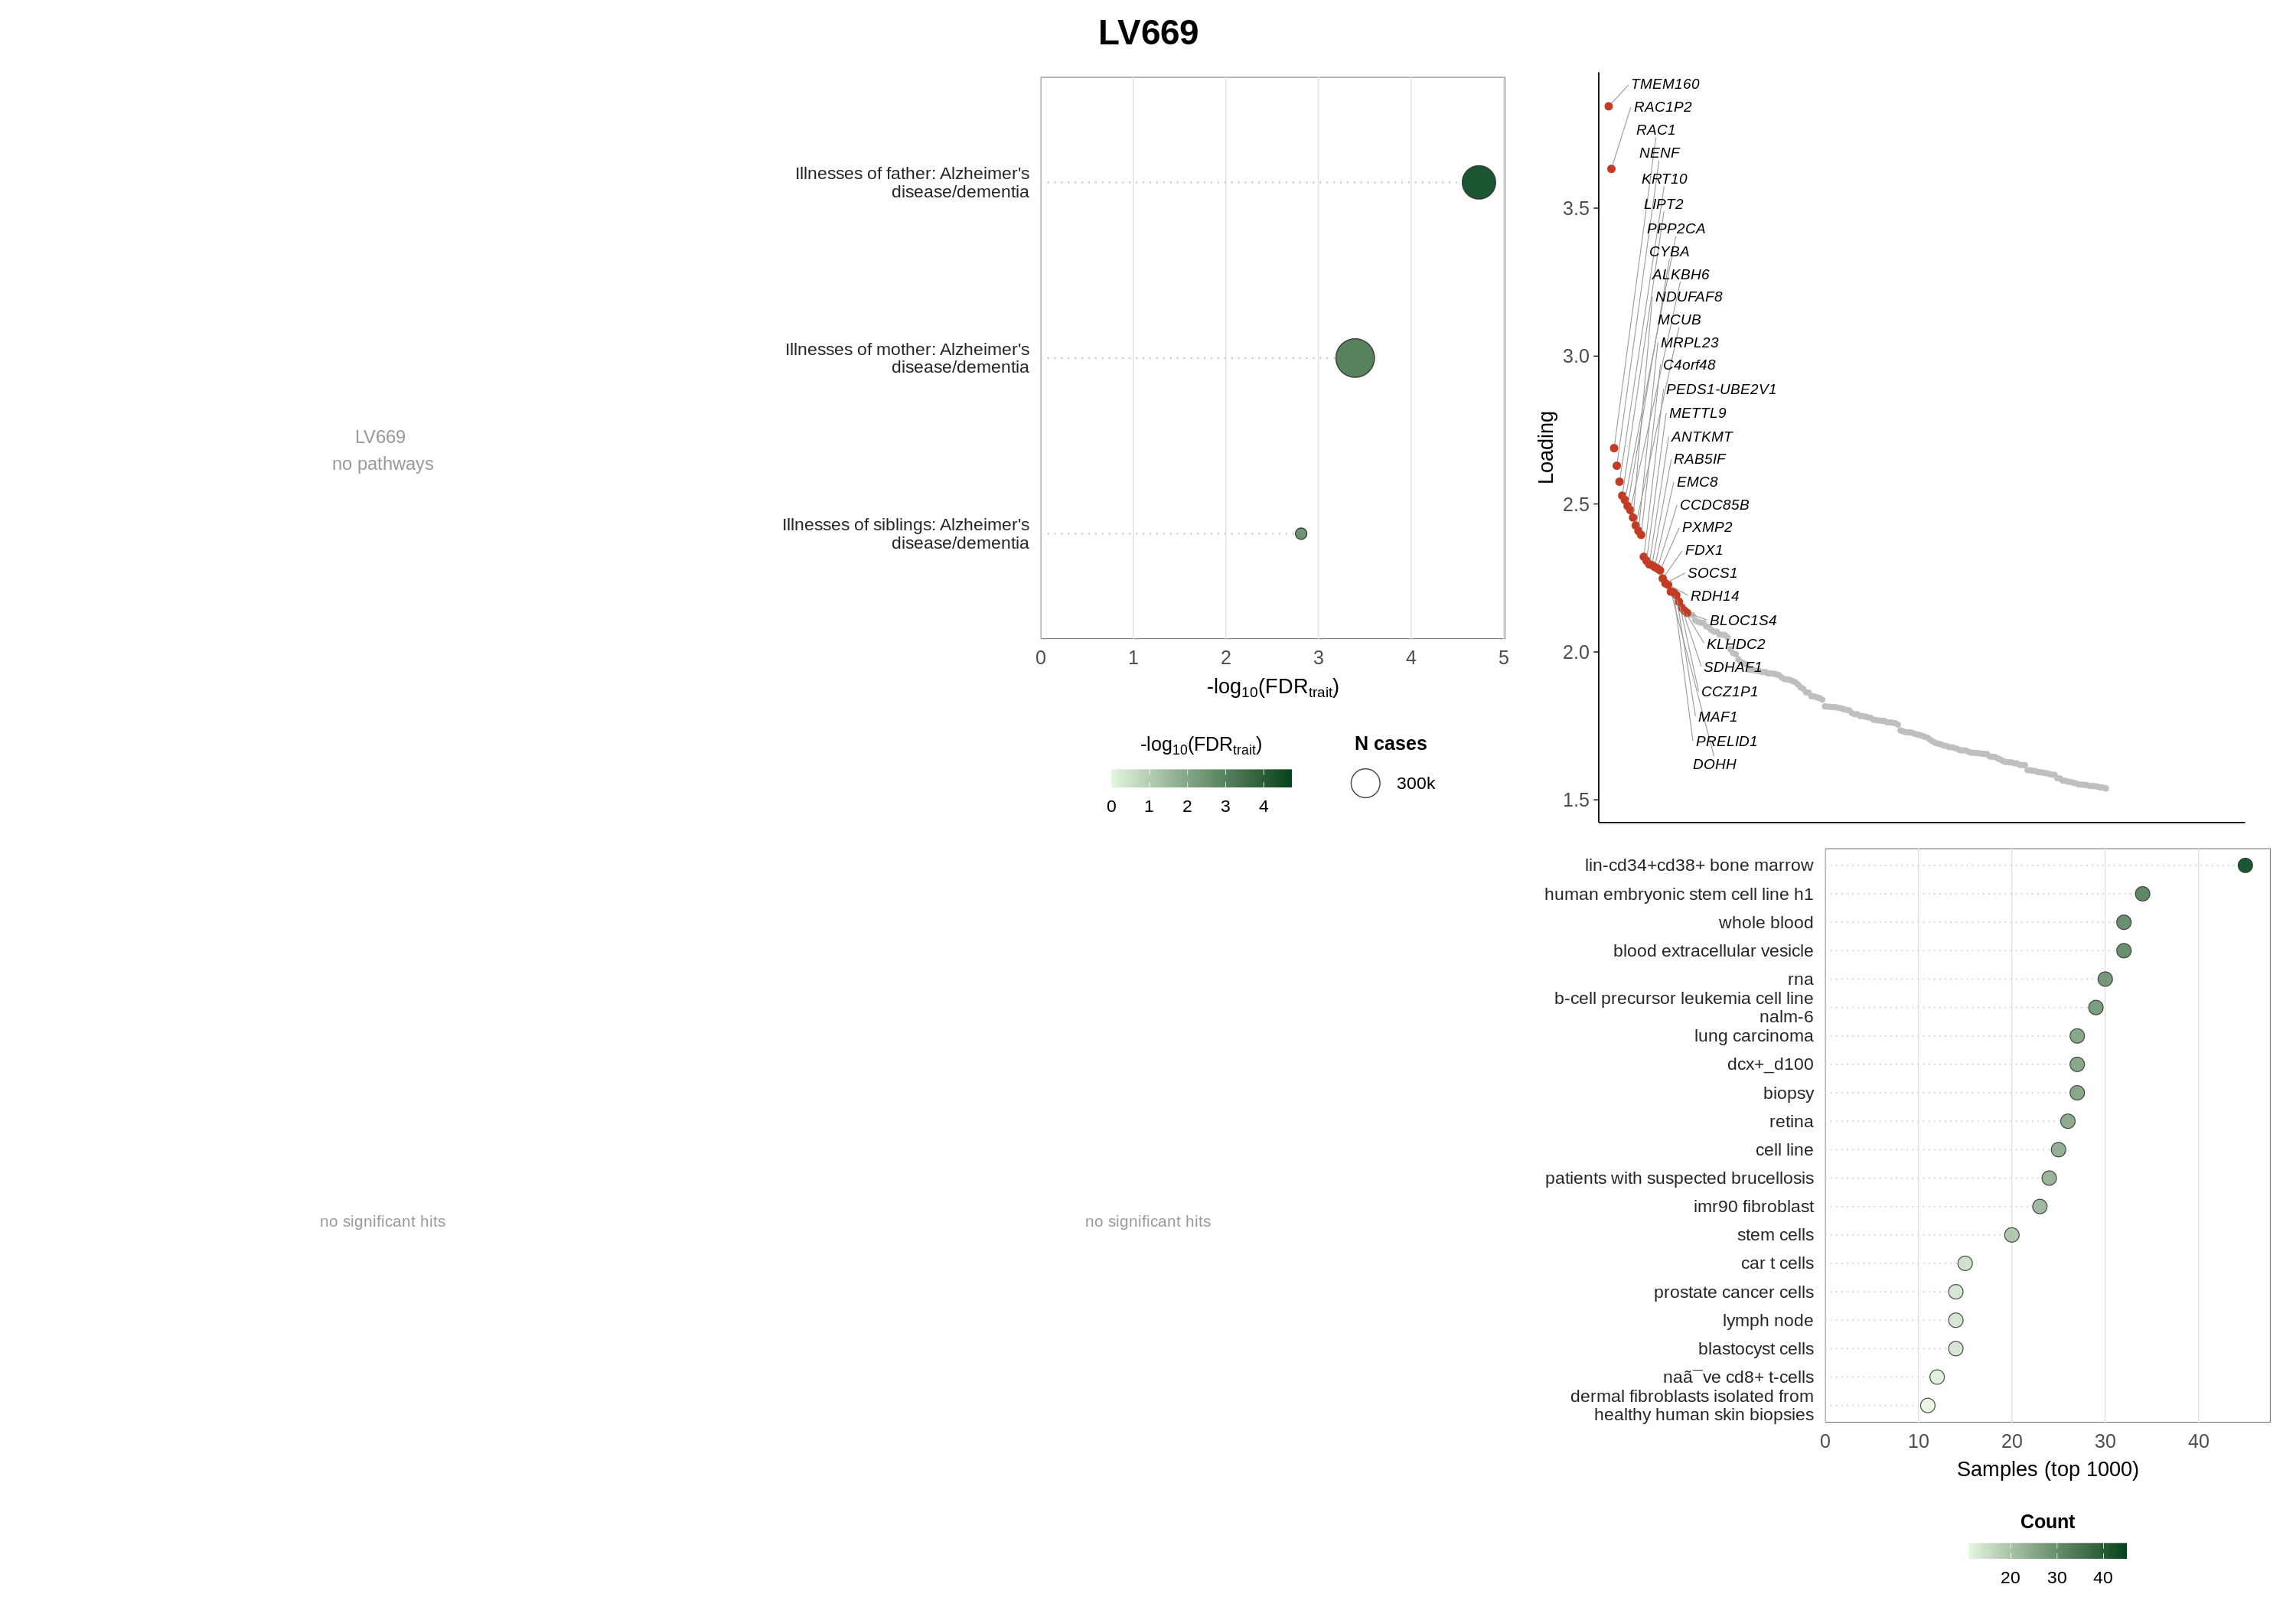

In [14]:
FIG_W   <- 20    # inches
FIG_H   <- 14    # inches
FIG_DPI <- 150

for (lv_name in LVS) {
  fig <- make_summary_figure(lv_name)
  tmp <- tempfile(fileext = ".png")
  # cairo PNG handles UTF-8 labels (curly quotes, accents) correctly
  png(tmp, width = FIG_W, height = FIG_H, units = "in", res = FIG_DPI,
      bg = "white", type = "cairo")
  print(fig)
  dev.off()
  IRdisplay::display_png(file = tmp)
  cat("\n")
}